In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# from the repository root or from the Notebooks folder.
ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "house_prices_cleaned_featured.csv"
REPORTS_PATH = ROOT / "reports"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Processed dataset:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the processed dataset at {DATA_PATH}. "
    )

Repository root: C:\Users\Hp\Desktop\K-LAB
Processed dataset: C:\Users\Hp\Desktop\K-LAB\data\processed\house_prices_cleaned_featured.csv


In [2]:
# Task 1: Load and Explore the Processed Dataset

# The dataset has already been cleaned, so this section only checks that it loaded correctly and inspects the columns needed for classification.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (4551, 24)

Columns:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country', 'city_listing_count', 'city_avg_price', 'city_median_price', 'city_avg_sqft_living', 'price_vs_city_avg', 'price_zscore']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,city_listing_count,city_avg_price,city_median_price,city_avg_sqft_living,price_vs_city_avg,price_zscore
0,2014-05-02,313000.0,3,1.50,1340,7912,1.5,0,0,3,...,18810 Densmore Ave N,Shoreline,WA 98133,USA,123,420392.364047,360000.0,1774.837398,-1.073924e+05,-0.434332
1,2014-05-02,2384000.0,5,2.50,3650,9050,2.0,0,4,5,...,709 W Blaine St,Seattle,WA 98119,USA,1561,584294.898165,490000.0,1826.242793,1.799705e+06,3.238514
2,2014-05-02,342000.0,3,2.00,1930,11947,1.0,0,0,4,...,26206-26214 143rd Ave SE,Kent,WA 98042,USA,184,441880.990543,283600.0,1980.190217,-9.988099e+04,-0.382902
3,2014-05-02,420000.0,3,2.25,2000,8030,1.0,0,0,4,...,857 170th Pl NE,Bellevue,WA 98008,USA,281,862255.052017,725000.0,2673.113879,-4.422551e+05,-0.244571
4,2014-05-02,550000.0,4,2.50,1940,10500,1.0,0,0,4,...,9105 170th Ave NE,Redmond,WA 98052,USA,235,667649.534781,638000.0,2491.761702,-1.176495e+05,-0.014021


In [4]:
# Task 2: Create the Premium Classification Target

# A house is labelled premium when its sale price is at least $1,000,000. The target is derived from price, so price itself is excluded from the model features to avoid target leakage.

In [5]:
PREMIUM_THRESHOLD = 1_000_000

df["premium"] = (
    df["price"] >= PREMIUM_THRESHOLD
).astype(int)

print("Premium threshold:", f"${PREMIUM_THRESHOLD:,}")

df[["price", "premium"]].head()

Premium threshold: $1,000,000


,price,premium
0,313000.0,0
1,2384000.0,1
2,342000.0,0
3,420000.0,0
4,550000.0,0


In [6]:
# Task 3: Check Class Distribution

# Classification metrics like accuracy can be misleading when one class is much rarer than the other, so the class balance is checked before any model is trained.

In [7]:
class_counts = df["premium"].value_counts().sort_index()
class_percentages = (
    df["premium"].value_counts(normalize=True).sort_index() * 100
)

print("CLASS DISTRIBUTION")
print("------------------")
print("Regular houses:", class_counts.get(0, 0))
print("Premium houses:", class_counts.get(1, 0))

print(f"\nRegular: {class_percentages.get(0, 0):.1f}%")
print(f"Premium: {class_percentages.get(1, 0):.1f}%")

CLASS DISTRIBUTION
------------------
Regular houses: 4207
Premium houses: 344

Regular: 92.4%
Premium: 7.6%


In [8]:
# Task 4: Select Features and Target

# Features:
# - sqft_living
# - yr_built
#
# Target:
# - premium
#
# price is excluded from the features because the target was created from price.

In [9]:
features = ["sqft_living", "yr_built"]
target = "premium"

required_columns = features + [target]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

model_df = df[required_columns].copy()

print("Selected columns:")
print(model_df.head())

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nSummary statistics:")
model_df.describe()

Selected columns:
   sqft_living  yr_built  premium
0         1340      1955        0
1         3650      1921        1
2         1930      1966        0
3         2000      1963        0
4         1940      1976        0

Missing values:
sqft_living    0
yr_built       0
premium        0
dtype: int64

Summary statistics:


,sqft_living,yr_built,premium
count,4551.000000,4551.000000,4551.000000
mean,2132.372226,1970.795649,0.075588
std,955.949708,29.760073,0.264366
min,370.000000,1900.000000,0.000000
25%,1460.000000,1951.000000,0.000000
50%,1970.000000,1976.000000,0.000000
75%,2610.000000,1997.000000,0.000000
max,13540.000000,2014.000000,1.000000


In [10]:
# Task 5: Prepare Training and Testing Data

# The data is split into:
#
# - 80% training data, used to teach the models.
# - 20% testing data, used to evaluate predictions on unseen houses.
#
# The split is stratified on the target so both sets keep the same premium/regular ratio as the full dataset.

In [11]:
# Remove any unexpected missing values only from the columns used here.
model_df = model_df.dropna().copy()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(f"\nPremium % in full dataset: {y.mean() * 100:.2f}%")
print(f"Premium % in training data: {y_train.mean() * 100:.2f}%")
print(f"Premium % in testing data: {y_test.mean() * 100:.2f}%")

Training rows: 3640
Testing rows: 911

Premium % in full dataset: 7.56%
Premium % in training data: 7.55%
Premium % in testing data: 7.57%


In [12]:
# Task 6: Build the Baseline Classifier

# The baseline always predicts the most frequent class. It shows why high accuracy can still be useless when the minority class is never found.

In [13]:
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(X_test)

print("Baseline classifier trained successfully.")

Baseline classifier trained successfully.


In [14]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions, zero_division=0)
baseline_recall = recall_score(y_test, baseline_predictions, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_predictions, zero_division=0)

print("BASELINE RESULTS")
print("----------------")
print(f"Accuracy:  {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall:    {baseline_recall:.3f}")
print(f"F1 Score:  {baseline_f1:.3f}")

BASELINE RESULTS
----------------
Accuracy:  0.924
Precision: 0.000
Recall:    0.000
F1 Score:  0.000


In [15]:
# Task 7: Build the Logistic Regression Model

# Logistic Regression estimates the probability that a house is premium using a linear combination of the selected features. Class weights are balanced because premium houses are rare.

In [16]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

print("\nIntercept:")
print(logistic_model.intercept_[0])

print("\nCoefficients:")
for feature, coefficient in zip(features, logistic_model.coef_[0]):
    print(f"{feature}: {coefficient:,.6f}")

Logistic Regression trained successfully.

Intercept:
41.17697779175713

Coefficients:
sqft_living: 0.002245
yr_built: -0.024006


In [17]:
log_accuracy = accuracy_score(y_test, logistic_predictions)
log_precision = precision_score(y_test, logistic_predictions, zero_division=0)
log_recall = recall_score(y_test, logistic_predictions, zero_division=0)
log_f1 = f1_score(y_test, logistic_predictions, zero_division=0)
log_auc = roc_auc_score(y_test, logistic_probabilities)

print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print(f"Accuracy:  {log_accuracy:.3f}")
print(f"Precision: {log_precision:.3f}")
print(f"Recall:    {log_recall:.3f}")
print(f"F1 Score:  {log_f1:.3f}")
print(f"ROC-AUC:   {log_auc:.3f}")

LOGISTIC REGRESSION RESULTS
---------------------------
Accuracy:  0.829
Precision: 0.292
Recall:    0.884
F1 Score:  0.439
ROC-AUC:   0.929


In [18]:
# Task 8: Logistic Regression Confusion Matrix

# The confusion matrix breaks the predictions down into true and false positives and negatives, which makes the precision/recall trade-off visible directly.

In [19]:
log_confusion = confusion_matrix(y_test, logistic_predictions)
tn, fp, fn, tp = log_confusion.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 694
False Positives: 148
False Negatives: 8
True Positives: 61


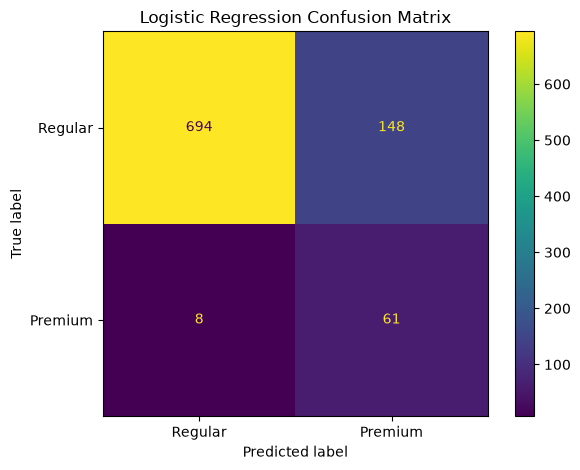

In [20]:
ConfusionMatrixDisplay(
    confusion_matrix=log_confusion,
    display_labels=["Regular", "Premium"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a4_logistic_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Task 9: Build the Random Forest Model

# Random Forest combines many decision trees. It can capture more complex and non-linear relationships than Logistic Regression.

In [22]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(X_test)
forest_probabilities = forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [23]:
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_precision = precision_score(y_test, forest_predictions, zero_division=0)
forest_recall = recall_score(y_test, forest_predictions, zero_division=0)
forest_f1 = f1_score(y_test, forest_predictions, zero_division=0)
forest_auc = roc_auc_score(y_test, forest_probabilities)

print("RANDOM FOREST RESULTS")
print("---------------------")
print(f"Accuracy:  {forest_accuracy:.3f}")
print(f"Precision: {forest_precision:.3f}")
print(f"Recall:    {forest_recall:.3f}")
print(f"F1 Score:  {forest_f1:.3f}")
print(f"ROC-AUC:   {forest_auc:.3f}")

RANDOM FOREST RESULTS
---------------------
Accuracy:  0.894
Precision: 0.379
Recall:    0.638
F1 Score:  0.476
ROC-AUC:   0.882


In [24]:
# Task 10: Compare Baseline, Logistic Regression, and Random Forest

# A higher F1 score is better for this comparison, since F1 balances precision and recall on the imbalanced premium class. Accuracy and ROC-AUC are reported alongside it for context.

In [25]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        log_accuracy,
        forest_accuracy
    ],
    "Precision": [
        baseline_precision,
        log_precision,
        forest_precision
    ],
    "Recall": [
        baseline_recall,
        log_recall,
        forest_recall
    ],
    "F1": [
        baseline_f1,
        log_f1,
        forest_f1
    ],
    "ROC_AUC": [
        np.nan,
        log_auc,
        forest_auc
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.924,0.000,0.000,0.000,NaN
1,Logistic Regression,0.829,0.292,0.884,0.439,0.929
2,Random Forest,0.894,0.379,0.638,0.476,0.882


In [26]:
model_results = results[
    results["Model"] != "Baseline"
].copy()

best_model_row = model_results.loc[
    model_results["F1"].idxmax()
]

best_model = best_model_row["Model"]
best_f1 = best_model_row["F1"]

print("MODEL COMPARISON")
print("----------------")

print(
    f"Best model based on the highest F1 score: "
    f"{best_model}"
)

print(
    f"\nLogistic Regression F1: "
    f"{log_f1:.3f}"
)

print(
    f"Random Forest F1: "
    f"{forest_f1:.3f}"
)

print(
    f"\nLogistic Regression ROC-AUC: "
    f"{log_auc:.3f}"
)

print(
    f"Random Forest ROC-AUC: "
    f"{forest_auc:.3f}"
)

MODEL COMPARISON
----------------
Best model based on the highest F1 score: Random Forest

Logistic Regression F1: 0.439
Random Forest F1: 0.476

Logistic Regression ROC-AUC: 0.929
Random Forest ROC-AUC: 0.882


In [27]:
# Task 11: Visualize the F1 Comparison

# The chart compares the F1 score achieved by Logistic Regression and Random Forest. The baseline is excluded because its F1 score of 0 would flatten the comparison.

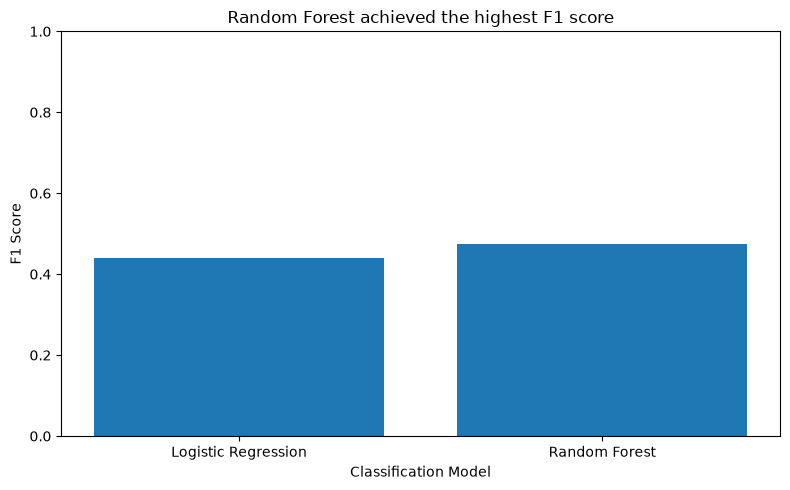

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["F1"]
)

plt.xlabel("Classification Model")
plt.ylabel("F1 Score")
plt.title(
    f"{best_model} achieved the highest F1 score"
)
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "a4_model_f1_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Task 12: Classification Report for the Best Model

# The classification report shows precision, recall, and F1 for each class separately, which is more informative than a single overall score.

In [30]:
if best_model == "Random Forest":
    best_predictions = forest_predictions
else:
    best_predictions = logistic_predictions

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Regular", "Premium"]
    )
)

              precision    recall  f1-score   support

     Regular       0.97      0.91      0.94       842
     Premium       0.38      0.64      0.48        69

    accuracy                           0.89       911
   macro avg       0.67      0.78      0.71       911
weighted avg       0.92      0.89      0.91       911



In [31]:
# Task 13: Final Conclusion

# Run the cell below after training both models. It creates a conclusion using the actual model results.

In [32]:
if forest_f1 > log_f1:
    conclusion = (
        "Random Forest is the model I would trust more for this task. "
        f"It achieved a higher F1 score ({forest_f1:.3f}) than Logistic Regression "
        f"({log_f1:.3f}), with precision of {forest_precision:.3f} and recall of "
        f"{forest_recall:.3f}. Random Forest can capture non-linear relationships "
        "and interactions between sqft_living and yr_built that a linear decision "
        "boundary cannot, which better separates premium houses from regular ones."
    )
else:
    conclusion = (
        "Logistic Regression is the model I would trust more for this task. "
        f"It achieved a higher F1 score ({log_f1:.3f}) than Random Forest "
        f"({forest_f1:.3f}), with precision of {log_precision:.3f} and recall of "
        f"{log_recall:.3f}. With only these two features, the simpler linear "
        "decision boundary generalized better to the test data."
    )

print(conclusion)

Random Forest is the model I would trust more for this task. It achieved a higher F1 score (0.476) than Logistic Regression (0.439), with precision of 0.379 and recall of 0.638. Random Forest can capture non-linear relationships and interactions between sqft_living and yr_built that a linear decision boundary cannot, which better separates premium houses from regular ones.


In [33]:
# Task 14: Generate the One-Page Report

# This produces a single markdown file summarizing the classification question, the metric choice, the results for the best model, and the business interpretation.

In [34]:
premium_count = int(y.sum())
regular_count = int((y == 0).sum())
premium_pct = y.mean() * 100

if best_model == "Random Forest":
    final_accuracy = forest_accuracy
    final_precision = forest_precision
    final_recall = forest_recall
    final_f1 = forest_f1
    final_auc = forest_auc
else:
    final_accuracy = log_accuracy
    final_precision = log_precision
    final_recall = log_recall
    final_f1 = log_f1
    final_auc = log_auc

report = f'''
# Classification Assignment: Predicting Premium House Listings

## Classification Question

The goal of this project was to predict whether a house should be classified as
a premium listing. A house was labelled premium when its sale price was at least
${PREMIUM_THRESHOLD:,}. The classifier used sqft_living and yr_built as predictor
variables.

The original price variable was not used as a model input because the premium
label was derived from price. Including it would create target leakage.

The dataset contained {regular_count:,} regular houses and
{premium_count:,} premium houses. Premium houses represented approximately
{premium_pct:.1f}% of the data.

## Metric Optimised

I used F1 score as the main evaluation metric.

Accuracy alone would not be enough because the classes are imbalanced. A model
could obtain high accuracy simply by predicting the more common regular class.
That model could still miss many premium houses, as shown by the baseline
classifier, which scored {baseline_accuracy:.3f} accuracy but {baseline_f1:.3f} F1.

F1 combines precision and recall. Precision measures how often houses predicted
as premium are actually premium, while recall measures how many real premium
houses the model successfully identifies.

## Model Results

The selected model was {best_model}.

Its test-set performance was:

- Accuracy: {final_accuracy:.3f}
- Precision: {final_precision:.3f}
- Recall: {final_recall:.3f}
- F1 score: {final_f1:.3f}
- ROC-AUC: {final_auc:.3f}

## Business Interpretation

{conclusion}
'''

report_path = REPORTS_PATH / "classification-assignment-report.md"

report_path.write_text(
    report.strip(),
    encoding="utf-8"
)

print("Report saved to:")
print(report_path)

Report saved to:
C:\Users\Hp\Desktop\K-LAB\reports\classification-assignment-report.md


In [35]:
# Final Notes

# Accuracy alone is not a reliable metric here because premium houses make up only a small share of the dataset. A model that predicts "regular" for every house can still reach high accuracy while missing every premium listing, as shown by the baseline classifier above.

# F1 score was used as the main comparison metric because a property business cares about both kinds of mistakes: false positives waste time reviewing or promoting ordinary listings as premium, while false negatives mean genuinely high-value houses are missed. F1 balances precision and recall, so it does not reward either mistake at the expense of the other.

# This assignment uses only sqft_living and yr_built so every model is evaluated on exactly the same information. The processed dataset contains additional engineered columns from Assignment 2, and price-derived columns were deliberately excluded to avoid target leakage.